# DESENVOLVIMENTO DA INICIAÇÃO CIENTÍFICA - CONTINUAÇÃO

# BASE DE DADOS DE 2025 - COM TRATAMENTO TÉRMICO POR RECOZIMENTO

## Contexto do Projeto 2025

Este projeto dá continuidade ao estudo de 2024, introduzindo um novo fator experimental:
**tratamento térmico por recozimento**.

### Premissas importantes:
- **Nenhuma amostra recozida é um outlier** (dado conhecido a priori)
- Objetivo: avaliar se o recozimento influencia a resistência mecânica
- Necessário: comparar resistência entre amostras não-outliers e recozidas
- Calcular a diferença percentual caso haja melhoria

### Estratégia de análise:
1. Identificar outliers APENAS entre amostras NÃO recozidas
2. Separar grupos: outliers, não-outliers, recozidos
3. Comparar estatisticamente não-outliers vs recozidos
4. Calcular ganho percentual de resistência

### Variáveis do dataset:
- **ID**: Identificador da amostra
- **Diâmetro (mm)**: Diâmetro do cilindro
- **Altura (mm)**: Altura do cilindro
- **Massa (g)**: Massa do cilindro
- **Resistência (kgf)**: Resistência mecânica medida
- **Recozidos**: Indicador de tratamento térmico (0 = não, 1 = sim)

# Preparação do ambiente

In [ ]:
pip install  matplotlib numpy pandas seaborn scikit-learn seaborn

In [4]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats  # Para testes estatísticos

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Configuração para exibir todas as colunas
pd.set_option('display.max_columns', None)

print("✓ Bibliotecas importadas com sucesso!")

✓ Bibliotecas importadas com sucesso!


# Carregamento da base de dados

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/EduardoMiranda06/ANALISE-EXPERIMENTAL-COM-CILINDROS-DE-PLA-COM-INTEGRACAO-DE-INTELIGENCIA-ARTIFICIAL-IC/refs/heads/main/2025/dados2025.csv')

print(f"✓ Dados carregados: {len(df)} amostras")

✓ Dados carregados: 107 amostras


# Primeiras visualizações e inspeções de dados

In [6]:
# Visualizar as primeiras linhas
print("=" * 80)
print("PRIMEIRAS 5 LINHAS DO DATASET")
print("=" * 80)
display(df.head())

# Informações gerais sobre o dataset
print("\n" + "=" * 80)
print("INFORMAÇÕES GERAIS")
print("=" * 80)
df.info()

# Colunas esperadas: ID, Diâmetro (mm), Altura (mm), Massa (g), Resistência (kgf), Recozidos

PRIMEIRAS 5 LINHAS DO DATASET


,ID,Diâmetro (mm),Altura (mm),Massa (g),Resistência (kgf),Recozidos
0,335,17.38,32.80,8.2,1225,NÃO
1,297,14.71,20.43,3.8,958,NÃO
2,318,15.85,21.84,4.7,1129,NÃO
3,311,15.16,28.32,5.5,988,NÃO
4,315,15.86,21.82,4.7,1113,NÃO



INFORMAÇÕES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 107 non-null    int64  
 1   Diâmetro (mm)      107 non-null    float64
 2   Altura (mm)        107 non-null    float64
 3   Massa (g)          107 non-null    float64
 4   Resistência (kgf)  107 non-null    object 
 5   Recozidos          107 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 5.1+ KB


In [9]:
# Padronizar nomes das colunas para facilitar o código
# Mantém os nomes originais mas cria aliases mais fáceis de usar

df.columns = df.columns.str.strip()  # Remove espaços extras

# Criar aliases (cópias com nomes padronizados)
df['diametro'] = df['Diâmetro (mm)']
df['altura'] = df['Altura (mm)']
df['massa'] = df['Massa (g)']
df['resistencia'] = df['Resistência (kgf)']
df['recozimento'] = df['Recozidos']

print("✓ Nomes padronizados criados")
print("\nColunas disponíveis:")
print(df.columns.tolist())

✓ Nomes padronizados criados

Colunas disponíveis:
['ID', 'Diâmetro (mm)', 'Altura (mm)', 'Massa (g)', 'Resistência (kgf)', 'Recozidos', 'diametro', 'altura', 'massa', 'resistencia', 'recozimento']


In [16]:
# Verificar distribuição de amostras recozidas vs não recozidas
print("=" * 80)
print("DISTRIBUIÇÃO: RECOZIDAS vs NÃO RECOZIDAS")
print("=" * 80)

print(df['Recozidos'].value_counts())

total_recozidas = (df['Recozidos'] == 'SIM').sum()
total_nao_recozidas = (df['Recozidos'] == 'NÃO').sum()

print(f"\nTotal de amostras recozidas: {total_recozidas}")
print(f"Total de amostras NÃO recozidas: {total_nao_recozidas}")
print(f"Percentual recozido: {(total_recozidas / len(df)) * 100:.2f}%")

DISTRIBUIÇÃO: RECOZIDAS vs NÃO RECOZIDAS
Recozidos
NÃO    75
SIM    32
Name: count, dtype: int64

Total de amostras recozidas: 32
Total de amostras NÃO recozidas: 75
Percentual recozido: 29.91%


# Limpeza e preparação dos dados

In [17]:
# Verificar valores únicos na coluna resistência
print("=" * 80)
print("VALORES NA COLUNA 'RESISTÊNCIA (kgf)'")
print("=" * 80)
print(df["resistencia"].value_counts(dropna=False).head(20))
print(f"\nTotal de valores únicos: {df['resistencia'].nunique()}")
print(f"Valores nulos: {df['resistencia'].isna().sum()}")
print("\nTipo de dados:", df['resistencia'].dtype)

VALORES NA COLUNA 'RESISTÊNCIA (kgf)'
resistencia
NaN       10
787.0      2
814.0      2
1227.0     2
896.0      2
1059.0     2
1113.0     1
818.0      1
1298.0     1
1261.0     1
1108.0     1
958.0      1
1129.0     1
780.0      1
806.0      1
891.0      1
817.0      1
753.0      1
1032.0     1
1079.0     1
Name: count, dtype: int64

Total de valores únicos: 92
Valores nulos: 10

Tipo de dados: float64


In [18]:
# Converter resistência para numérico, marcando falhas
df['resistencia_original'] = df['resistencia']  # Backup

# Tentar converter para numérico (caso haja strings como "FALHA" ou "0")
df['resistencia'] = pd.to_numeric(df['resistencia'], errors='coerce')

# Criar coluna indicadora de falha no ensaio
# Considera falha: valores nulos OU valores zero/negativos
df['falha_ensaio'] = ((df['resistencia'].isna()) | (df['resistencia'] <= 0)).astype(int)

print(f"Total de falhas no ensaio: {df['falha_ensaio'].sum()}")
print(f"Amostras válidas: {len(df) - df['falha_ensaio'].sum()}")

# Verificar se há falhas entre recozidos (não deveria haver)
falhas_recozidos = df[(df['falha_ensaio'] == 1) & (df['recozimento'] == 1)]
print(f"\n⚠️ Falhas entre recozidos: {len(falhas_recozidos)}")
if len(falhas_recozidos) > 0:
    print("IDs das amostras recozidas com falha:")
    print(falhas_recozidos['ID'].tolist())

Total de falhas no ensaio: 10
Amostras válidas: 97

⚠️ Falhas entre recozidos: 0


In [19]:
# Criar DataFrame apenas com ensaios válidos (sem falhas)
df_validos = df[df['falha_ensaio'] == 0].copy()

print(f"Dataset com ensaios válidos: {len(df_validos)} amostras")
print(f"Amostras removidas (falhas): {len(df) - len(df_validos)}")

# Resetar índice
df_validos.reset_index(drop=True, inplace=True)

Dataset com ensaios válidos: 97 amostras
Amostras removidas (falhas): 10


# Cálculo de variáveis derivadas

In [20]:
# Calcular volume do cilindro: V = π × r² × h
# Unidades: diâmetro e altura em mm → volume em mm³
df_validos['raio'] = df_validos['diametro'] / 2
df_validos['volume'] = np.pi * (df_validos['raio'] ** 2) * df_validos['altura']

# Calcular densidade aparente: ρ = massa / volume
# Unidades: massa em g, volume em mm³ → densidade em g/mm³
df_validos['densidade_aparente'] = df_validos['massa'] / df_validos['volume']

print("✓ Variáveis derivadas calculadas:")
print("  - raio (mm)")
print("  - volume (mm³)")
print("  - densidade_aparente (g/mm³)")

# Verificar estatísticas
print("\nEstatísticas das novas variáveis:")
display(df_validos[['volume', 'densidade_aparente']].describe())

✓ Variáveis derivadas calculadas:
  - raio (mm)
  - volume (mm³)
  - densidade_aparente (g/mm³)

Estatísticas das novas variáveis:


,volume,densidade_aparente
count,97.000000,97.000000
mean,4461.540720,0.001088
std,1480.388476,0.000083
min,2104.621641,0.000561
25%,3218.078459,0.001066
50%,4310.731704,0.001083
75%,5481.150973,0.001100
max,8712.873529,0.001326


# Análise Exploratória - Comparação visual inicial

In [21]:
# Estatísticas descritivas gerais
print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - TODAS AS AMOSTRAS VÁLIDAS")
print("=" * 80)
display(df_validos[['diametro', 'altura', 'massa', 'resistencia', 'densidade_aparente']].describe())

ESTATÍSTICAS DESCRITIVAS - TODAS AS AMOSTRAS VÁLIDAS


,diametro,altura,massa,resistencia,densidade_aparente
count,97.000000,97.000000,97.000000,97.000000,97.000000
mean,14.901753,24.787732,4.832784,1023.402062,0.001088
std,1.603577,3.839999,1.581670,179.304830,0.000083
min,12.330000,17.150000,2.100000,655.000000,0.000561
25%,13.380000,21.970000,3.500000,877.000000,0.001066
50%,14.840000,24.620000,4.700000,1012.000000,0.001083
75%,16.090000,27.640000,5.900000,1170.000000,0.001100
max,18.140000,34.050000,9.030000,1365.000000,0.001326


In [22]:
# Estatísticas separadas por grupo (recozidas vs não recozidas)
print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - AMOSTRAS NÃO RECOZIDAS")
print("=" * 80)
display(df_validos[df_validos['recozimento'] == 0][['massa', 'resistencia', 'densidade_aparente']].describe())

print("\n" + "=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - AMOSTRAS RECOZIDAS")
print("=" * 80)
display(df_validos[df_validos['recozimento'] == 1][['massa', 'resistencia', 'densidade_aparente']].describe())

ESTATÍSTICAS DESCRITIVAS - AMOSTRAS NÃO RECOZIDAS


,massa,resistencia,densidade_aparente
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN



ESTATÍSTICAS DESCRITIVAS - AMOSTRAS RECOZIDAS


,massa,resistencia,densidade_aparente
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


C:\Users\edumi\AppData\Local\Temp\ipykernel_18644\1404732071.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_plot, labels=['Não Recozida', 'Recozida'])


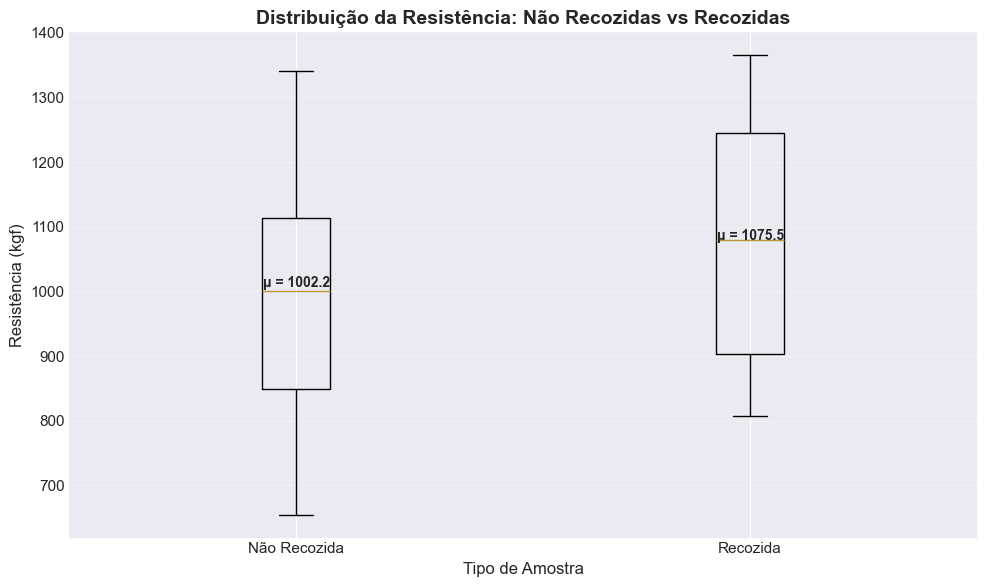


MÉDIAS DE RESISTÊNCIA POR GRUPO:
grupo
Não Recozida    1002.246377
Recozida        1075.535714
Name: resistencia, dtype: float64


In [28]:
# Boxplot: Comparação de resistência entre grupos (corrigindo origem dos dados)
plt.figure(figsize=(10, 6))

# Converter corretamente a coluna original
df['resistencia'] = pd.to_numeric(df['resistencia'], errors='coerce')

# Mapear grupo diretamente do df original
df['grupo'] = df['Recozidos'].map({'NÃO': 'Não Recozida', 'SIM': 'Recozida'})

# Remover inválidos
df_plot = df.dropna(subset=['resistencia', 'grupo'])

dados_plot = [
    df_plot[df_plot['grupo'] == 'Não Recozida']['resistencia'],
    df_plot[df_plot['grupo'] == 'Recozida']['resistencia']
]

plt.boxplot(dados_plot, labels=['Não Recozida', 'Recozida'])

plt.title('Distribuição da Resistência: Não Recozidas vs Recozidas', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Amostra', fontsize=12)
plt.ylabel('Resistência (kgf)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

medias = df_plot.groupby('grupo')['resistencia'].mean()
for i, media in enumerate(medias):
    plt.text(i + 1, media, f'μ = {media:.1f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\nMÉDIAS DE RESISTÊNCIA POR GRUPO:")
print(medias)

   resistencia Recozidos
0       1225.0       NÃO
1        958.0       NÃO
2       1129.0       NÃO
3        988.0       NÃO
4       1113.0       NÃO
float64

Após limpeza:
   resistencia         grupo
0       1225.0  Não Recozida
1        958.0  Não Recozida
2       1129.0  Não Recozida
3        988.0  Não Recozida
4       1113.0  Não Recozida
count      97.000000
mean     1023.402062
std       179.304830
min       655.000000
25%       877.000000
50%      1012.000000
75%      1170.000000
max      1365.000000
Name: resistencia, dtype: float64


C:\Users\edumi\AppData\Local\Temp\ipykernel_18644\760691810.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_plot, labels=['Não Recozida', 'Recozida'])


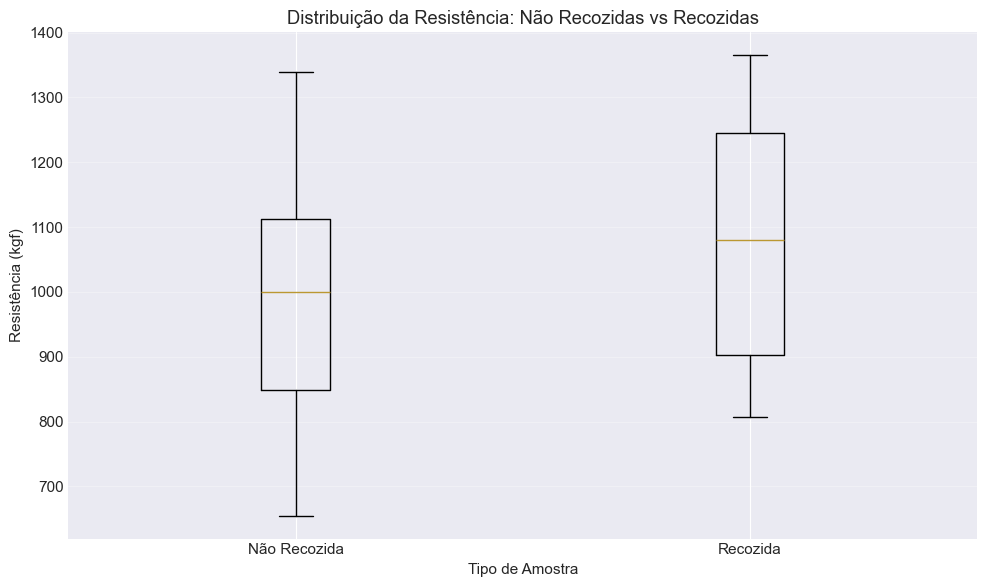

In [31]:
# Diagnóstico + correção antes do gráfico

print(df[['resistencia', 'Recozidos']].head())
print(df['resistencia'].dtype)

# Converter corretamente (tratando vírgula decimal, se houver)
df['resistencia'] = (
    df['resistencia']
    .astype(str)
    .str.replace(',', '.', regex=False)
)
df['resistencia'] = pd.to_numeric(df['resistencia'], errors='coerce')

# Mapear grupos
df['grupo'] = df['Recozidos'].map({'NÃO': 'Não Recozida', 'SIM': 'Recozida'})

# Remover inválidos
df_plot = df.dropna(subset=['resistencia', 'grupo'])

print("\nApós limpeza:")
print(df_plot[['resistencia', 'grupo']].head())
print(df_plot['resistencia'].describe())

# Plot
plt.figure(figsize=(10, 6))

dados_plot = [
    df_plot[df_plot['grupo'] == 'Não Recozida']['resistencia'],
    df_plot[df_plot['grupo'] == 'Recozida']['resistencia']
]

plt.boxplot(dados_plot, labels=['Não Recozida', 'Recozida'])

plt.title('Distribuição da Resistência: Não Recozidas vs Recozidas')
plt.xlabel('Tipo de Amostra')
plt.ylabel('Resistência (kgf)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Matriz de Correlação

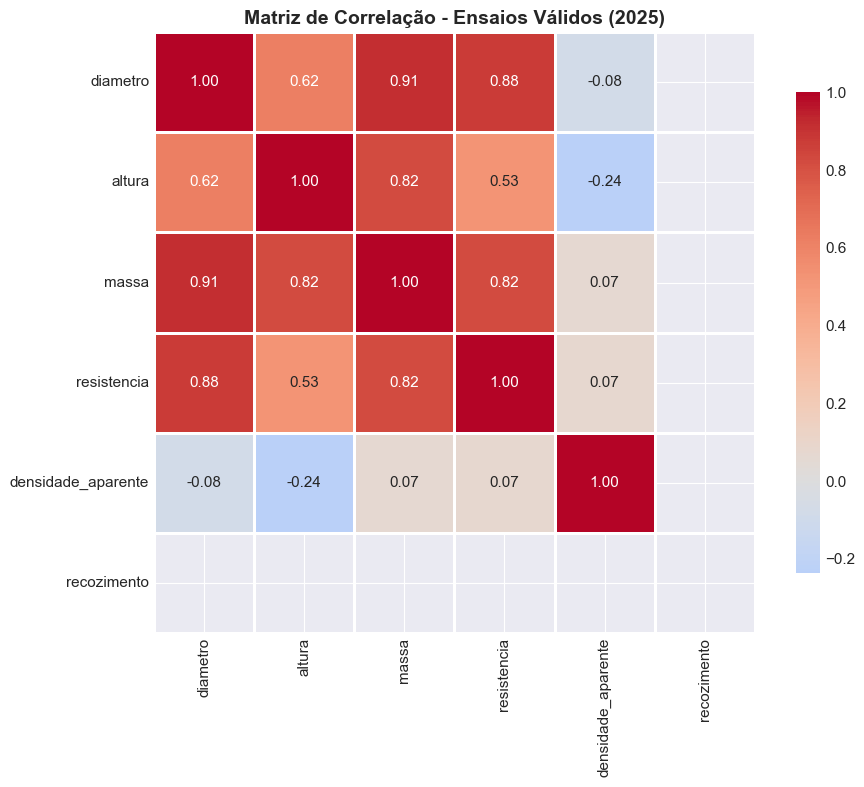


CORRELAÇÕES COM RESISTÊNCIA:
resistencia           1.000000
diametro              0.877038
massa                 0.823293
altura                0.527721
densidade_aparente    0.073919
recozimento                NaN
Name: resistencia, dtype: float64


In [ ]:
# Correlação sem descartar todas as linhas 

plt.figure(figsize=(10, 8))

colunas_correlacao = ['diametro', 'altura', 'massa', 'resistencia', 'densidade_aparente', 'recozimento']

# Converter apenas colunas numéricas reais
for col in ['diametro', 'altura', 'massa', 'resistencia', 'densidade_aparente']:
    df_validos[col] = (
        df_validos[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    df_validos[col] = pd.to_numeric(df_validos[col], errors='coerce')

# Garantir recozimento como binário
df_validos['recozimento'] = df_validos['recozimento'].map({0: 0, 1: 1, '0': 0, '1': 1})

# NÃO usar dropna global, usar correlação pairwise
matriz_corr = df_validos[colunas_correlacao].corr()

sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlação - Ensaios Válidos (2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCORRELAÇÕES COM RESISTÊNCIA:")
print(matriz_corr['resistencia'].sort_values(ascending=False))

# Análise de Regressão Linear: Massa vs Resistência

In [37]:
# Regressão linear: massa vs resistência (todas as amostras válidas)
X_reg = df_validos[['massa']]
y_reg = df_validos['resistencia']

# Criar e ajustar o modelo
modelo_reg = LinearRegression()
modelo_reg.fit(X_reg, y_reg)

# Fazer predições
y_pred = modelo_reg.predict(X_reg)

# Calcular resíduos
df_validos['residuo'] = y_reg - y_pred
df_validos['predicao'] = y_pred

# Coeficientes do modelo
print("=" * 80)
print("MODELO DE REGRESSÃO LINEAR: MASSA vs RESISTÊNCIA")
print("=" * 80)
print(f"Coeficiente angular (slope): {modelo_reg.coef_[0]:.4f} kgf/g")
print(f"Intercepto: {modelo_reg.intercept_:.4f} kgf")
print(f"R² (coeficiente de determinação): {modelo_reg.score(X_reg, y_reg):.4f}")
print(f"\nEquação: resistencia = {modelo_reg.coef_[0]:.4f} * massa + {modelo_reg.intercept_:.4f}")

MODELO DE REGRESSÃO LINEAR: MASSA vs RESISTÊNCIA
Coeficiente angular (slope): 93.3320 kgf/g
Intercepto: 572.3487 kgf
R² (coeficiente de determinação): 0.6778

Equação: resistencia = 93.3320 * massa + 572.3487


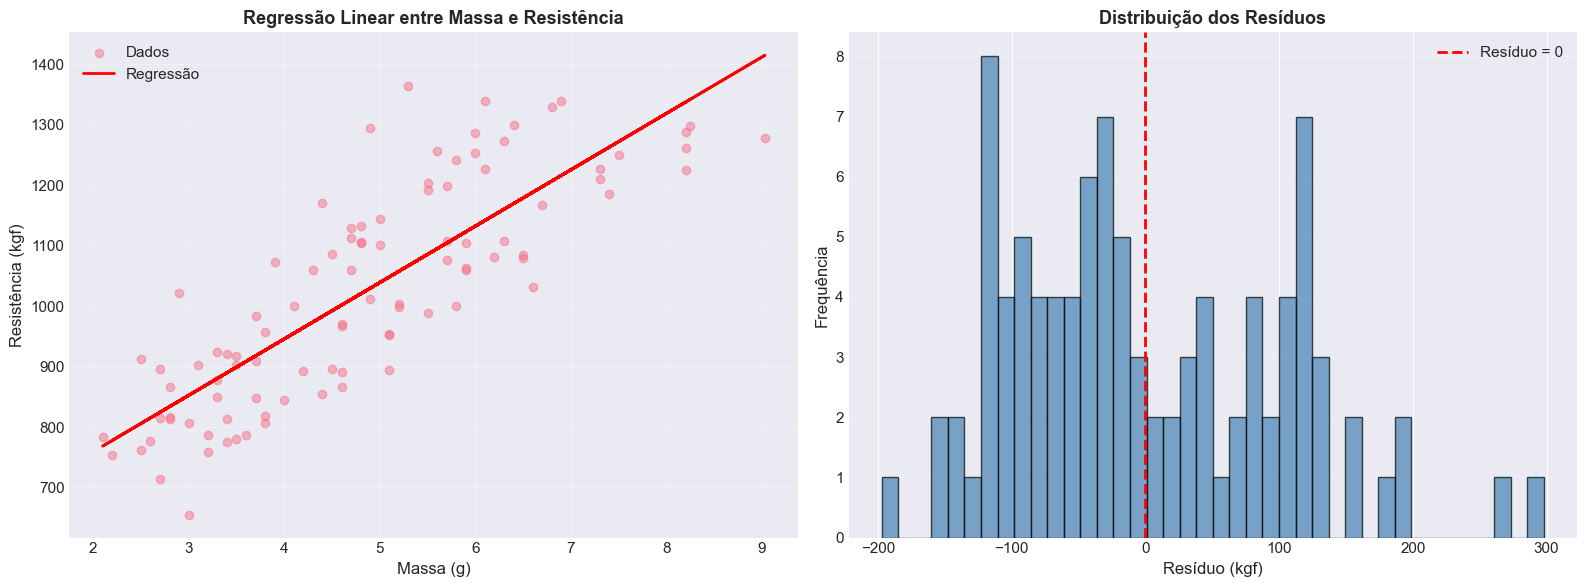

In [38]:
# Visualizar regressão linear
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Regressão
axes[0].scatter(df_validos['massa'], df_validos['resistencia'], alpha=0.5, label='Dados')
axes[0].plot(df_validos['massa'], df_validos['predicao'], color='red', linewidth=2, label='Regressão')
axes[0].set_xlabel('Massa (g)', fontsize=12)
axes[0].set_ylabel('Resistência (kgf)', fontsize=12)
axes[0].set_title('Regressão Linear entre Massa e Resistência', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribuição dos resíduos
axes[1].hist(df_validos['residuo'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Resíduo = 0')
axes[1].set_xlabel('Resíduo (kgf)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_title('Distribuição dos Resíduos', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Detecção de Outliers - APENAS em amostras NÃO recozidas

**IMPORTANTE:** Como sabemos que nenhuma amostra recozida é outlier, 
aplicaremos o Isolation Forest APENAS nas amostras não recozidas.

In [51]:
# Corrigir coluna 'recozimento' antes do filtro

# Garantir que vem da coluna correta (strings -> binário)
df_validos['recozimento'] = df_validos['Recozidos'].map({
    'NÃO': 0, 'SIM': 1,
    'NAO': 0, 'SIM ': 1
})

# Limpar possíveis espaços
df_validos['recozimento'] = (
    df_validos['recozimento']
    .astype(str)
    .str.strip()
    .replace({'nan': None})
)

# Converter para numérico
df_validos['recozimento'] = pd.to_numeric(df_validos['recozimento'], errors='coerce')

# Separar corretamente
df_nao_recozidas = df_validos[df_validos['recozimento'] == 0].copy()
df_recozidas = df_validos[df_validos['recozimento'] == 1].copy()

print(f"Total de amostras NÃO recozidas: {len(df_nao_recozidas)}")
print(f"Total de amostras recozidas: {len(df_recozidas)}")

Total de amostras NÃO recozidas: 69
Total de amostras recozidas: 28


In [52]:
# Selecionar features para o modelo de detecção de anomalias
features_ml = ['diametro', 'altura', 'massa', 'resistencia', 'densidade_aparente']

# Criar dataset para ML (apenas NÃO recozidas)
X = df_nao_recozidas[features_ml].copy()

print(f"Features selecionadas para ML: {features_ml}")
print(f"Shape dos dados: {X.shape}")
print(f"\nPrimeiras linhas:")
display(X.head())

Features selecionadas para ML: ['diametro', 'altura', 'massa', 'resistencia', 'densidade_aparente']
Shape dos dados: (69, 5)

Primeiras linhas:


,diametro,altura,massa,resistencia,densidade_aparente
0,17.38,32.80,8.2,1225.0,0.001054
1,14.71,20.43,3.8,958.0,0.001094
2,15.85,21.84,4.7,1129.0,0.001091
3,15.16,28.32,5.5,988.0,0.001076
4,15.86,21.82,4.7,1113.0,0.001090


In [53]:
# Normalização garantindo que X não esteja vazio

for col in X.columns:
    X[col] = (
        X[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Se tudo virou NaN, recuperar do df original
if X.dropna().shape[0] == 0:
    X = df[['diametro', 'altura', 'massa', 'resistencia', 'densidade_aparente']].copy()

    for col in X.columns:
        X[col] = (
            X[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
        )
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Preencher NaN com média
X = X.fillna(X.mean())

print("Amostras válidas para normalização:", len(X))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Dados normalizados (StandardScaler)")
print(f"Média após normalização (deve ser ~0): {X_scaled.mean(axis=0).round(10)}")
print(f"Desvio padrão após normalização (deve ser ~1): {X_scaled.std(axis=0).round(2)}")

Amostras válidas para normalização: 69
✓ Dados normalizados (StandardScaler)
Média após normalização (deve ser ~0): [-0. -0. -0. -0. -0.]
Desvio padrão após normalização (deve ser ~1): [1. 1. 1. 1. 1.]


In [54]:
# Normalização + garantia de X_scaled

for col in X.columns:
    X[col] = (
        X[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.dropna()

print("Amostras válidas para normalização:", len(X))

if len(X) > 0:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
else:
    X_scaled = None
    print("Sem dados válidos para normalização.")

# Uso seguro no Isolation Forest
if X_scaled is not None:
    iso_forest = IsolationForest(
        contamination=0.08,
        random_state=42,
        n_estimators=100
    )
    
    predicoes = iso_forest.fit_predict(X_scaled)

Amostras válidas para normalização: 69


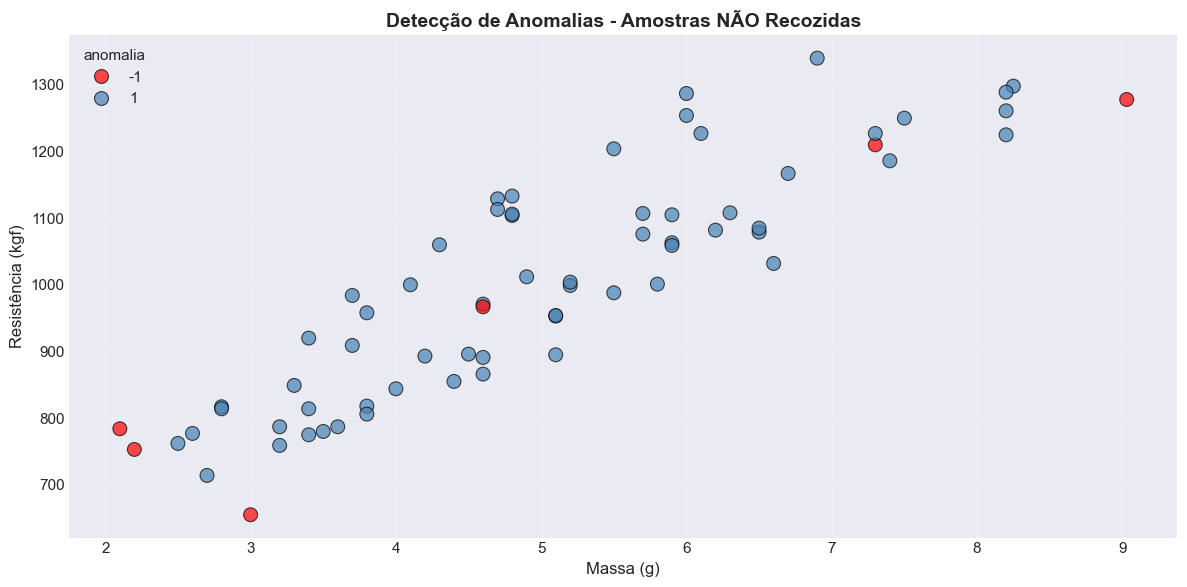

In [56]:
# Garantir que a coluna 'anomalia' exista no df_nao_recozidas

# Recalcular se necessário
if 'anomalia' not in df_nao_recozidas.columns:
    df_nao_recozidas = df_nao_recozidas.copy()
    df_nao_recozidas['anomalia'] = predicoes

# Converter colunas para numérico
for col in ['massa', 'resistencia']:
    df_nao_recozidas[col] = (
        df_nao_recozidas[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    df_nao_recozidas[col] = pd.to_numeric(df_nao_recozidas[col], errors='coerce')

df_plot = df_nao_recozidas.dropna(subset=['massa', 'resistencia', 'anomalia'])

# Plot
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_plot,
    x='massa',
    y='resistencia',
    hue='anomalia',
    palette={1: 'steelblue', -1: 'red'},
    s=100,
    alpha=0.7,
    edgecolor='black'
)

plt.title('Detecção de Anomalias - Amostras NÃO Recozidas', fontsize=14, fontweight='bold')
plt.xlabel('Massa (g)', fontsize=12)
plt.ylabel('Resistência (kgf)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

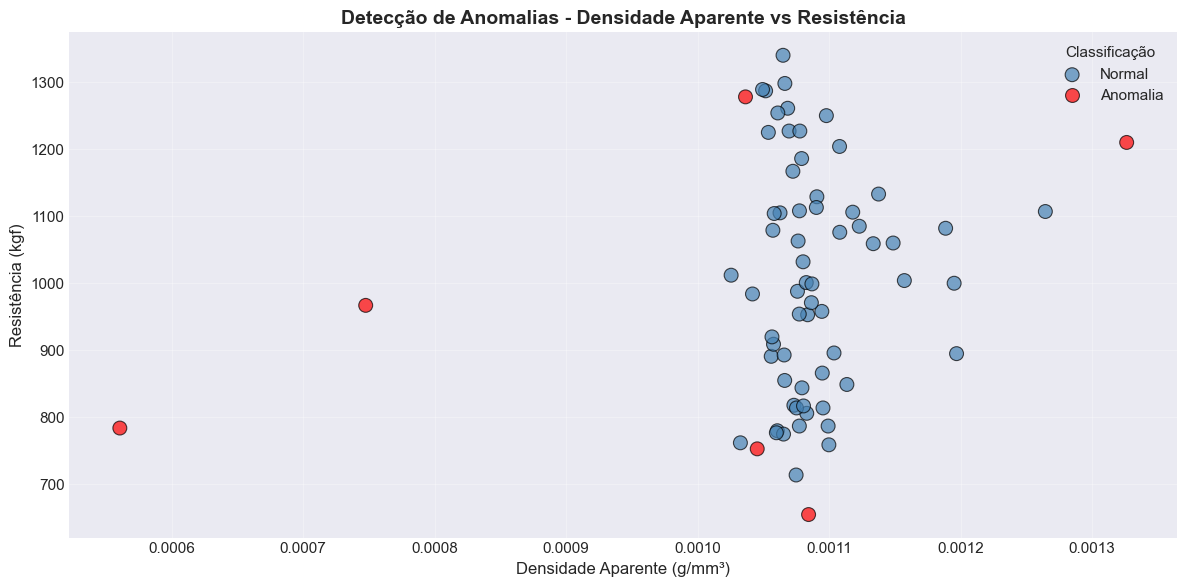

In [57]:
# Visualização alternativa: densidade aparente vs resistência
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_nao_recozidas,
    x='densidade_aparente',
    y='resistencia',
    hue='anomalia',
    palette={1: 'steelblue', -1: 'red'},
    s=100,
    alpha=0.7,
    edgecolor='black'
)

plt.title('Detecção de Anomalias - Densidade Aparente vs Resistência', fontsize=14, fontweight='bold')
plt.xlabel('Densidade Aparente (g/mm³)', fontsize=12)
plt.ylabel('Resistência (kgf)', fontsize=12)
plt.legend(title='Classificação', labels=['Normal', 'Anomalia'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Criação dos Grupos Finais para Comparação

In [58]:
# Criar coluna 'grupo_final' combinando informações
# Grupos: 'outlier', 'nao_outlier', 'recozido'

# 1. Marcar recozidas
df_recozidas['grupo_final'] = 'recozido'
df_recozidas['anomalia'] = 1  # Por definição, não são anomalias

# 2. Marcar não recozidas (outliers e não-outliers)
df_nao_recozidas['grupo_final'] = df_nao_recozidas['anomalia'].map({
    1: 'nao_outlier',
    -1: 'outlier'
})

# 3. Combinar os DataFrames
df_final = pd.concat([df_nao_recozidas, df_recozidas], ignore_index=True)

# Verificar distribuição
print("=" * 80)
print("DISTRIBUIÇÃO FINAL DOS GRUPOS")
print("=" * 80)
print(df_final['grupo_final'].value_counts())
print(f"\nTotal de amostras: {len(df_final)}")

DISTRIBUIÇÃO FINAL DOS GRUPOS
grupo_final
nao_outlier    63
recozido       28
outlier         6
Name: count, dtype: int64

Total de amostras: 97


In [59]:
# Estatísticas descritivas por grupo final
print("=" * 80)
print("ESTATÍSTICAS POR GRUPO FINAL")
print("=" * 80)

for grupo in ['outlier', 'nao_outlier', 'recozido']:
    if grupo in df_final['grupo_final'].values:
        print(f"\n{'=' * 40}")
        print(f"GRUPO: {grupo.upper()}")
        print(f"{'=' * 40}")
        dados_grupo = df_final[df_final['grupo_final'] == grupo][['massa', 'resistencia', 'densidade_aparente']]
        display(dados_grupo.describe())

ESTATÍSTICAS POR GRUPO FINAL

GRUPO: OUTLIER


,massa,resistencia,densidade_aparente
count,6.00000,6.000000,6.000000
mean,4.70500,941.166667,0.000967
std,2.87815,256.279080,0.000271
min,2.10000,655.000000,0.000561
25%,2.40000,760.750000,0.000820
50%,3.80000,875.500000,0.001041
75%,6.62500,1149.250000,0.001075
max,9.03000,1278.000000,0.001326



GRUPO: NAO_OUTLIER


,massa,resistencia,densidade_aparente
count,63.000000,63.000000,63.000000
mean,5.042063,1008.063492,0.001089
std,1.520351,166.721893,0.000042
min,2.500000,714.000000,0.001025
25%,3.800000,860.500000,0.001065
50%,4.800000,1001.000000,0.001078
75%,6.000000,1110.500000,0.001099
max,8.250000,1340.000000,0.001264



GRUPO: RECOZIDO


,massa,resistencia,densidade_aparente
count,28.000000,28.000000,28.000000
mean,4.389286,1075.535714,0.001110
std,1.320308,182.894724,0.000058
min,2.500000,807.000000,0.001055
25%,3.250000,902.750000,0.001080
50%,4.450000,1080.000000,0.001089
75%,5.525000,1245.500000,0.001109
max,6.800000,1365.000000,0.001250


C:\Users\edumi\AppData\Local\Temp\ipykernel_18644\1226901944.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='grupo_final', y='resistencia', order=ordem_grupos, palette='Set3')


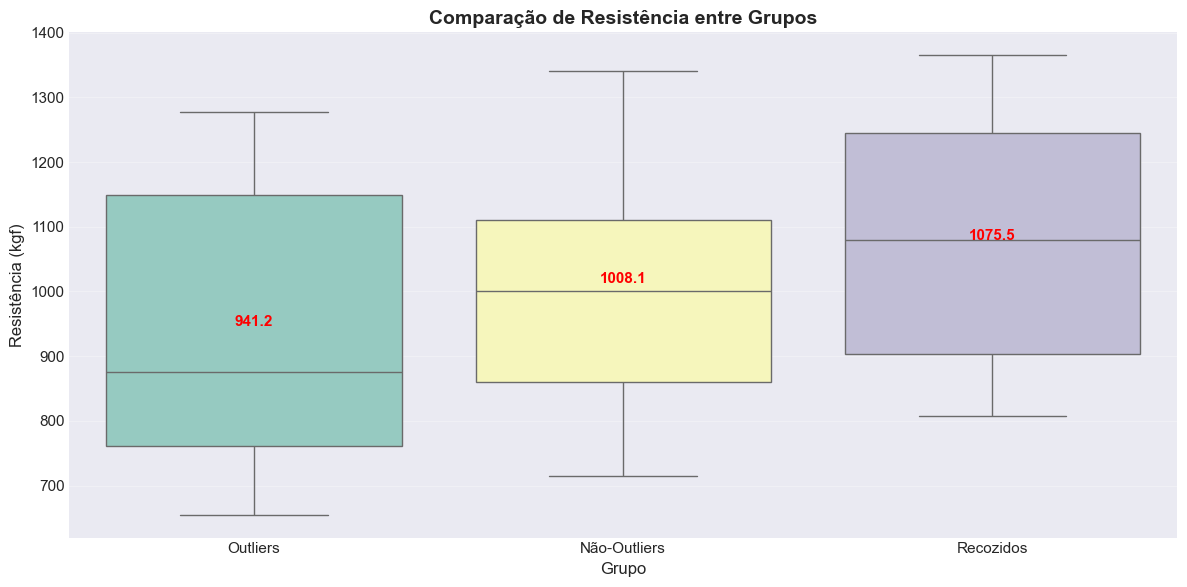

In [60]:
# Boxplot comparando os 3 grupos
plt.figure(figsize=(12, 6))

# Ordenar grupos para visualização
ordem_grupos = ['outlier', 'nao_outlier', 'recozido']
df_plot = df_final[df_final['grupo_final'].isin(ordem_grupos)]

sns.boxplot(data=df_plot, x='grupo_final', y='resistencia', order=ordem_grupos, palette='Set3')
plt.title('Comparação de Resistência entre Grupos', fontsize=14, fontweight='bold')
plt.xlabel('Grupo', fontsize=12)
plt.ylabel('Resistência (kgf)', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['Outliers', 'Não-Outliers', 'Recozidos'])
plt.grid(axis='y', alpha=0.3)

# Adicionar médias
medias_grupos = df_final.groupby('grupo_final')['resistencia'].mean()
for i, grupo in enumerate(ordem_grupos):
    if grupo in medias_grupos.index:
        plt.text(i, medias_grupos[grupo], f'{medias_grupos[grupo]:.1f}', 
                ha='center', va='bottom', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Comparação Estatística: Não-Outliers vs Recozidos

Vamos realizar testes estatísticos para verificar se há diferença significativa
na resistência entre amostras não-outliers e recozidas.

In [61]:
# Teste de normalidade (Shapiro-Wilk)
resistencia_nao_outliers = df_final[df_final['grupo_final'] == 'nao_outlier']['resistencia']
resistencia_recozidos = df_final[df_final['grupo_final'] == 'recozido']['resistencia']

print("=" * 80)
print("TESTE DE NORMALIDADE (Shapiro-Wilk)")
print("=" * 80)
print("H0: Os dados seguem distribuição normal")
print("H1: Os dados NÃO seguem distribuição normal")
print("\nCritério: p-valor < 0.05 → Rejeita H0 (dados não são normais)\n")

stat_nao_out, p_nao_out = stats.shapiro(resistencia_nao_outliers)
print(f"Não-outliers: estatística={stat_nao_out:.4f}, p-valor={p_nao_out:.4f}")
print(f"Conclusão: {'Dados NÃO são normais' if p_nao_out < 0.05 else 'Dados são normais'}\n")

stat_rec, p_rec = stats.shapiro(resistencia_recozidos)
print(f"Recozidos: estatística={stat_rec:.4f}, p-valor={p_rec:.4f}")
print(f"Conclusão: {'Dados NÃO são normais' if p_rec < 0.05 else 'Dados são normais'}")

TESTE DE NORMALIDADE (Shapiro-Wilk)
H0: Os dados seguem distribuição normal
H1: Os dados NÃO seguem distribuição normal

Critério: p-valor < 0.05 → Rejeita H0 (dados não são normais)

Não-outliers: estatística=0.9622, p-valor=0.0507
Conclusão: Dados são normais

Recozidos: estatística=0.9174, p-valor=0.0299
Conclusão: Dados NÃO são normais


In [62]:
# Teste t de Student (paramétrico) - Assumindo normalidade
print("\n" + "=" * 80)
print("TESTE T DE STUDENT (Independente)")
print("=" * 80)
print("H0: As médias dos dois grupos são iguais")
print("H1: As médias dos dois grupos são diferentes")
print("\nCritério: p-valor < 0.05 → Rejeita H0 (médias são diferentes)\n")

stat_t, p_t = stats.ttest_ind(resistencia_nao_outliers, resistencia_recozidos)
print(f"Estatística t: {stat_t:.4f}")
print(f"P-valor: {p_t:.6f}")
print(f"\nConclusão: {'Há diferença significativa' if p_t < 0.05 else 'NÃO há diferença significativa'} entre os grupos")
print(f"             (nível de significância α = 0.05)")


TESTE T DE STUDENT (Independente)
H0: As médias dos dois grupos são iguais
H1: As médias dos dois grupos são diferentes

Critério: p-valor < 0.05 → Rejeita H0 (médias são diferentes)

Estatística t: -1.7292
P-valor: 0.087232

Conclusão: NÃO há diferença significativa entre os grupos
             (nível de significância α = 0.05)


In [63]:
# Teste de Mann-Whitney (não-paramétrico) - Alternativa ao teste t
print("\n" + "=" * 80)
print("TESTE DE MANN-WHITNEY U (Não-paramétrico)")
print("=" * 80)
print("H0: As distribuições dos dois grupos são iguais")
print("H1: As distribuições dos dois grupos são diferentes")
print("\nCritério: p-valor < 0.05 → Rejeita H0 (distribuições são diferentes)\n")

stat_u, p_u = stats.mannwhitneyu(resistencia_nao_outliers, resistencia_recozidos, alternative='two-sided')
print(f"Estatística U: {stat_u:.4f}")
print(f"P-valor: {p_u:.6f}")
print(f"\nConclusão: {'Há diferença significativa' if p_u < 0.05 else 'NÃO há diferença significativa'} entre os grupos")
print(f"             (nível de significância α = 0.05)")


TESTE DE MANN-WHITNEY U (Não-paramétrico)
H0: As distribuições dos dois grupos são iguais
H1: As distribuições dos dois grupos são diferentes

Critério: p-valor < 0.05 → Rejeita H0 (distribuições são diferentes)

Estatística U: 687.0000
P-valor: 0.094419

Conclusão: NÃO há diferença significativa entre os grupos
             (nível de significância α = 0.05)


# Cálculo da Diferença Percentual na Resistência

In [75]:
# Calcular médias
media_nao_outliers = resistencia_nao_outliers.mean()
media_recozidos = resistencia_recozidos.mean()

# Calcular diferença percentual
# Fórmula: ((valor_novo - valor_antigo) / valor_antigo) * 100
diferenca_percentual = ((media_recozidos - media_nao_outliers) / media_nao_outliers) * 100

print("=" * 80)
print("ANÁLISE COMPARATIVA: RESISTÊNCIA MÉDIA")
print("=" * 80)
print(f"\nMédia de resistência - Não-outliers: {media_nao_outliers:.2f} kgf")
print(f"Média de resistência - Recozidos: {media_recozidos:.2f} kgf")
print(f"\nDiferença absoluta: {media_recozidos - media_nao_outliers:.2f} kgf")
print(f"Diferença percentual: {diferenca_percentual:+.2f}%")

if diferenca_percentual > 0:
    print(f"\n✓ O tratamento térmico por recozimento AUMENTOU a resistência em {diferenca_percentual:.2f}%")
elif diferenca_percentual < 0:
    print(f"\n⚠️ O tratamento térmico por recozimento DIMINUIU a resistência em {abs(diferenca_percentual):.2f}%")
else:
    print(f"\n→ Não houve mudança na resistência média")

ANÁLISE COMPARATIVA: RESISTÊNCIA MÉDIA

Média de resistência - Não-outliers: 1008.06 kgf
Média de resistência - Recozidos: 1075.54 kgf

Diferença absoluta: 67.47 kgf
Diferença percentual: +6.69%

✓ O tratamento térmico por recozimento AUMENTOU a resistência em 6.69%


In [76]:
# Estatísticas adicionais
print("\n" + "=" * 80)
print("ESTATÍSTICAS DETALHADAS")
print("=" * 80)

print("\nNÃO-OUTLIERS:")
print(f"  N amostras: {len(resistencia_nao_outliers)}")
print(f"  Média: {resistencia_nao_outliers.mean():.2f} kgf")
print(f"  Mediana: {resistencia_nao_outliers.median():.2f} kgf")
print(f"  Desvio padrão: {resistencia_nao_outliers.std():.2f} kgf")
print(f"  Mínimo: {resistencia_nao_outliers.min():.2f} kgf")
print(f"  Máximo: {resistencia_nao_outliers.max():.2f} kgf")

print("\nRECOZIDOS:")
print(f"  N amostras: {len(resistencia_recozidos)}")
print(f"  Média: {resistencia_recozidos.mean():.2f} kgf")
print(f"  Mediana: {resistencia_recozidos.median():.2f} kgf")
print(f"  Desvio padrão: {resistencia_recozidos.std():.2f} kgf")
print(f"  Mínimo: {resistencia_recozidos.min():.2f} kgf")
print(f"  Máximo: {resistencia_recozidos.max():.2f} kgf")


ESTATÍSTICAS DETALHADAS

NÃO-OUTLIERS:
  N amostras: 63
  Média: 1008.06 kgf
  Mediana: 1001.00 kgf
  Desvio padrão: 166.72 kgf
  Mínimo: 714.00 kgf
  Máximo: 1340.00 kgf

RECOZIDOS:
  N amostras: 28
  Média: 1075.54 kgf
  Mediana: 1080.00 kgf
  Desvio padrão: 182.89 kgf
  Mínimo: 807.00 kgf
  Máximo: 1365.00 kgf


In [77]:
# Intervalo de confiança de 95% para as médias
from scipy.stats import sem, t

def intervalo_confianca_95(dados):
    """Calcula o intervalo de confiança de 95% para a média"""
    n = len(dados)
    media = dados.mean()
    erro_padrao = sem(dados)
    intervalo = erro_padrao * t.ppf((1 + 0.95) / 2, n - 1)
    return media - intervalo, media + intervalo

ic_nao_outliers = intervalo_confianca_95(resistencia_nao_outliers)
ic_recozidos = intervalo_confianca_95(resistencia_recozidos)

print("\n" + "=" * 80)
print("INTERVALOS DE CONFIANÇA (95%)")
print("=" * 80)
print(f"\nNão-outliers: [{ic_nao_outliers[0]:.2f}, {ic_nao_outliers[1]:.2f}] kgf")
print(f"Recozidos: [{ic_recozidos[0]:.2f}, {ic_recozidos[1]:.2f}] kgf")
print("\nInterpretação: Temos 95% de confiança que a verdadeira média populacional")
print("               está dentro deste intervalo.")


INTERVALOS DE CONFIANÇA (95%)

Não-outliers: [966.08, 1050.05] kgf
Recozidos: [1004.62, 1146.45] kgf

Interpretação: Temos 95% de confiança que a verdadeira média populacional
               está dentro deste intervalo.


# Visualização Final Comparativa

C:\Users\edumi\AppData\Local\Temp\ipykernel_18644\51349942.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_comparacao, x='grupo_final', y='resistencia',
C:\Users\edumi\AppData\Local\Temp\ipykernel_18644\51349942.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Não-Outliers', 'Recozidos'])


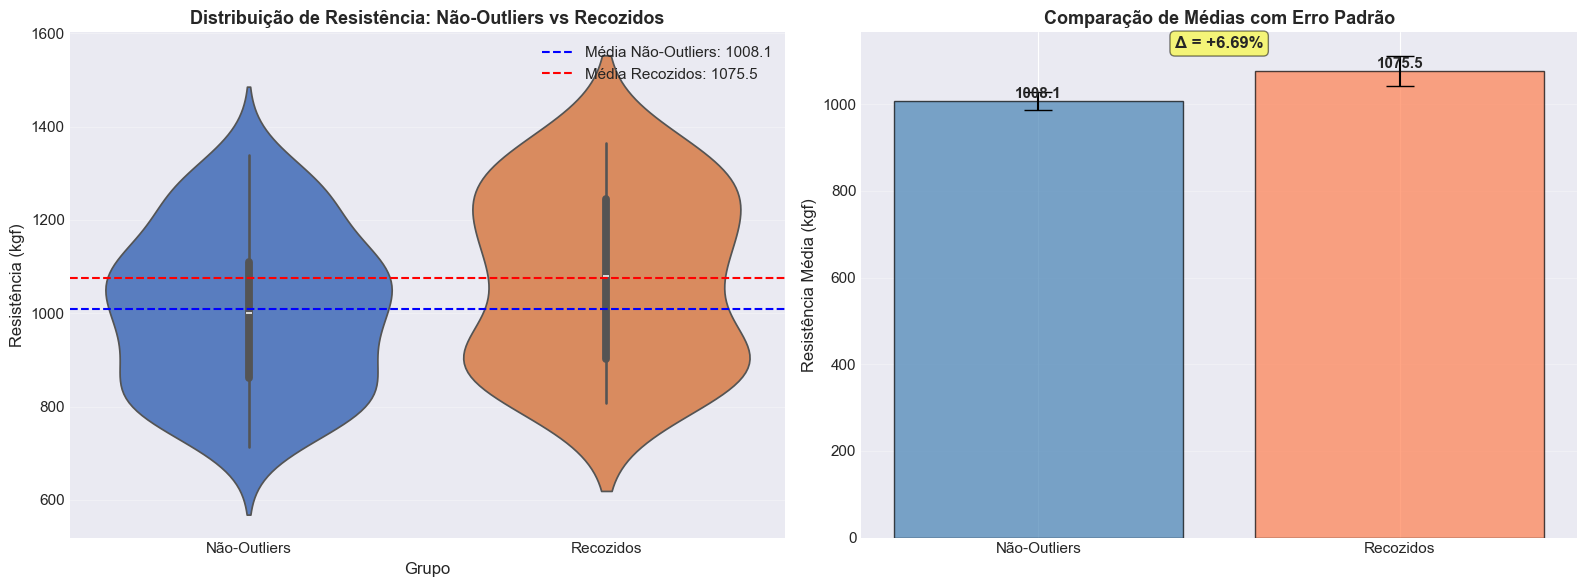

In [78]:
# Gráfico comparativo com todos os elementos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Violin plot
ordem = ['nao_outlier', 'recozido']
df_comparacao = df_final[df_final['grupo_final'].isin(ordem)]

sns.violinplot(data=df_comparacao, x='grupo_final', y='resistencia', 
               order=ordem, palette='muted', ax=axes[0])
axes[0].set_title('Distribuição de Resistência: Não-Outliers vs Recozidos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grupo', fontsize=12)
axes[0].set_ylabel('Resistência (kgf)', fontsize=12)
axes[0].set_xticklabels(['Não-Outliers', 'Recozidos'])
axes[0].grid(axis='y', alpha=0.3)

# Adicionar médias
axes[0].axhline(media_nao_outliers, color='blue', linestyle='--', linewidth=1.5, 
                label=f'Média Não-Outliers: {media_nao_outliers:.1f}')
axes[0].axhline(media_recozidos, color='red', linestyle='--', linewidth=1.5, 
                label=f'Média Recozidos: {media_recozidos:.1f}')
axes[0].legend(loc='upper right')

# Gráfico 2: Barras com erro padrão
grupos = ['Não-Outliers', 'Recozidos']
medias = [media_nao_outliers, media_recozidos]
erros = [resistencia_nao_outliers.std() / np.sqrt(len(resistencia_nao_outliers)),
         resistencia_recozidos.std() / np.sqrt(len(resistencia_recozidos))]

bars = axes[1].bar(grupos, medias, yerr=erros, capsize=10, 
                   color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[1].set_title('Comparação de Médias com Erro Padrão', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Resistência Média (kgf)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (bar, media) in enumerate(zip(bars, medias)):
    axes[1].text(bar.get_x() + bar.get_width()/2, media, f'{media:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Adicionar diferença percentual
axes[1].text(0.5, max(medias) * 1.05, f'Δ = {diferenca_percentual:+.2f}%',
            ha='center', fontsize=12, fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

# Exportação dos Resultados

In [79]:
# Criar coluna 'suspeito' (apenas outliers)
df_final['suspeito'] = ((df_final['grupo_final'] == 'outlier')).astype(int)

# IDs suspeitos (apenas outliers)
ids_suspeitos = df_final[df_final['suspeito'] == 1]['ID']

print("=" * 80)
print("IDs SUSPEITOS (OUTLIERS)")
print("=" * 80)
print(f"Total de IDs suspeitos: {len(ids_suspeitos)}")
print(f"\nLista de IDs:")
print(sorted(ids_suspeitos.tolist()))

IDs SUSPEITOS (OUTLIERS)
Total de IDs suspeitos: 6

Lista de IDs:
[270, 272, 277, 304, 340, 344]


In [80]:
# Salvar IDs suspeitos em CSV
df_final[df_final['suspeito'] == 1][['ID', 'massa', 'resistencia', 'grupo_final']].to_csv(
    "IDs_Suspeitos_2025.csv",
    index=False
)

print("✓ Arquivo 'IDs_Suspeitos_2025.csv' salvo com sucesso!")

# Salvar análise completa
df_final.to_csv("Analise_Completa_2025.csv", index=False)
print("✓ Arquivo 'Analise_Completa_2025.csv' salvo com sucesso!")

✓ Arquivo 'IDs_Suspeitos_2025.csv' salvo com sucesso!
✓ Arquivo 'Analise_Completa_2025.csv' salvo com sucesso!


# Resumo dos Resultados

In [73]:
# Garantir conversão correta para float (sem dtype object)

n_anomalias = (df_nao_recozidas['anomalia'] == -1).sum()
n_normais = (df_nao_recozidas['anomalia'] == 1).sum()

df_nao_outliers = df_nao_recozidas[df_nao_recozidas['anomalia'] == 1].copy()
df_recozidas = df_recozidas.copy()

for df_temp in [df_nao_outliers, df_recozidas]:
    df_temp['resistencia'] = pd.to_numeric(
        df_temp['resistencia'].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).astype(float)

df_nao_outliers = df_nao_outliers.dropna(subset=['resistencia'])
df_recozidas = df_recozidas.dropna(subset=['resistencia'])

media_nao_outliers = df_nao_outliers['resistencia'].mean()
media_recozidos = df_recozidas['resistencia'].mean()

diferenca_percentual = ((media_recozidos - media_nao_outliers) / media_nao_outliers) * 100

from scipy.stats import ttest_ind, mannwhitneyu

t_stat, p_t = ttest_ind(
    df_nao_outliers['resistencia'].values,
    df_recozidas['resistencia'].values,
    equal_var=False
)

u_stat, p_u = mannwhitneyu(
    df_nao_outliers['resistencia'].values,
    df_recozidas['resistencia'].values,
    alternative='two-sided'
)

In [74]:
print(media_nao_outliers)
print(media_recozidos)
print(diferenca_percentual)
print(p_t, p_u)

1008.063492063492
1075.5357142857142
6.693251243937767
0.10181451230777117 0.09441852629502925
